# Régression multiple

Une variable quantitative $Y$ dite à expliquer (ou encore, réponse, exogène, dépendante) est mise en relation avec $p$ variables quantitatives $X_1,\dots,X_p$ dites explicatives.

Les données sont supposées provenir de l'observation d'un échantillon statistique de taille $n$, $(n > p + 1)$ de $R^{(p+1)}$ :

$$
(x^1_i,\dots,x^j_i,\dots,x^p_i,y_i ),\quad i = 1,\dots,n.
$$

L'écriture du modèle linéaire dans cette situation conduit à supposer que l'espérance de $Y$ appartient au sous-espace de $R^n$ engendré par $X=\{1, X^1 ,\dots , X^p \}$ où 1 désigne le vecteur de $R^n$. C'est-à-dire que les $(p + 1)$ variables aléatoires vérifient :

$$
Y_i =\beta_0 +\beta_1X_i^1 +\beta_2X_i^2 +\dots+\beta_pX_i^p +\varepsilon_i, \quad i = 1,\dots,n.
$$

Les $\varepsilon_i$ sont des termes d'erreur indépendants et identiquement distribués tels que $\mathbb E(\varepsilon_i)=0$ et ${\rm Var}(\varepsilon_i)=\sigma^2$.

Les données sont rangées dans une matrice $X\in \mathbb R^{n\times(p + 1)}$ de terme général $X_i^j$, dont la première colonne contient le vecteur 1 $(X_0^i = 1)$, et dans un vecteur $Y$ de terme général $Y_i$. En notant les vecteurs $\varepsilon = [\varepsilon_1, \dots, \varepsilon_n]′$ et $\beta= [\beta_0, \beta_1, \dots \beta_p ]′$ , le modèle s'écrit matriciellement :

$$
Y = X\beta + \varepsilon
$$

Conditionnellement à la connaissance des valeurs des $X_j$, les paramètres inconnus du modèle : le vecteur $\beta$ et $\sigma^2$ (paramètre de nuisance), sont estimés par minimisation des carrés des écarts. 

L'expression à minimiser sur $\beta\in \mathbb R^{p+1}$ s'écrit :
\begin{align*}
\sum_{i=1}^n(Y_i −\beta_0 −\beta_1X_i^1 −\dots−\beta_pX_i^p)^2&=\|Y−X\beta\|^2_2\\
&= Y′Y − 2\beta′X′Y + \beta′X′X\beta
\end{align*}

Par dérivation matricielle de la dernière équation on obtient les équations normales :
$$
X′Y − X′X\beta = 0
$$
dont la solution correspond bien à un minimum car la matrice hessienne $2X′X$
est semi définie-positive.
Nous faisons l'hypothèse supplémentaire que la matrice $X′X$ est inversible, c’est-à-dire que la matrice $X$ est de rang $(p + 1)$ et donc qu'il n'existe pas de colinéarité entre ses colonnes. Si cette hypothèse n'est pas vérifiée, il suffit en principe de supprimer des colonnes de X et donc des variables du modèle. Une approche de réduction de dimension (régression ridge, Lasso, PLS ...) est à mettre en œuvre.
Alors, l’estimation des paramètres $\beta_j$ est donnée par :


$$
\hat \beta= (X′X)^{-1}X′Y
$$

et les valeurs ajustées (ou estimées, prédites) de $Y$ ont pour expression :

$$
\hat Y􏰞= X\hat \beta􏰞 = X(X′X)^{−1}X′Y = HY
$$

où $H=X(X′X)^{−1}X′$. Géométriquement, c'est la matrice de projection orthogonale dans $R^n$ sur le sous-espace ${\rm Vect}(X)$ engendré par les vecteurs colonnes de $X$. On note
$$
e=Y−\hat Y􏰞 =Y−X\hat \beta􏰞=(I−H)Y
$$


## Régression ridge

Soit le modèle linéaire :

$$
 Y=\tilde X {\tilde{􏰟\beta}􏰟}+\varepsilon
$$

where 

$$\tilde X=
\begin{pmatrix} 
1 & X^1_1 & X^2_1 &\dots & X^p_1\\
1 & X^1_2 & X^2_2 &\dots & X^p_2 \\
\vdots & \vdots & \vdots & \vdots \\
1 & X^1_n & X^2_n &\dots & X^p_n
\end{pmatrix}
$$

$$
\tilde{\beta}=\begin{pmatrix} 
\beta_0\\
\beta_1\\
\vdots \\
\beta_p
\end{pmatrix},
\quad
{\beta}=\begin{pmatrix} 
\beta_1\\
\beta_2\\
\vdots \\
\beta_p
\end{pmatrix}
$$

où $X_0 = (1,1,\dots,1)′$, et $X$ désigne la matrice $\tilde X$􏰟 privée de sa première colonne. L'estimateur ridge est défini par un critère des moindres carrés, avec une pénalité de type $L_2$ :

L'estimateur ridge de $\tilde \beta$ dans le modèle
$$
 Y=\tilde X {\tilde{􏰟\beta}􏰟}+\varepsilon
$$
est défini par :

$$
\hat{\beta}_{\rm ridge}:={\arg\min}_{\beta\in \mathbb R^{(p+1)}}\left(\sum_{i=1}^n (Y_i- \sum_{j=0}^pX_i^j\beta_j)^2+\lambda\sum_{j=0}^p \beta_j^2 \right)
$$
où $\lambda$ est un paramètre positif, à choisir.


Cela revient à chercher $${\arg\min}_{\beta\in \mathbb R^{(p+1)}}\left(\sum_{i=1}^n (Y_i- \sum_{j=0}^pX_i^j\beta_j)^2\right)$$

sous la contrainte supplémentaire :

$$
\|\beta\|_2^2=\sum_{j=0}^p \beta_j^2 \leq \frac{1}{\lambda}
$$

          x         y
0  1.047198  0.795794
1  1.117011  0.775370
2  1.186824  0.917377
3  1.256637  0.844052
4  1.326450  1.106248


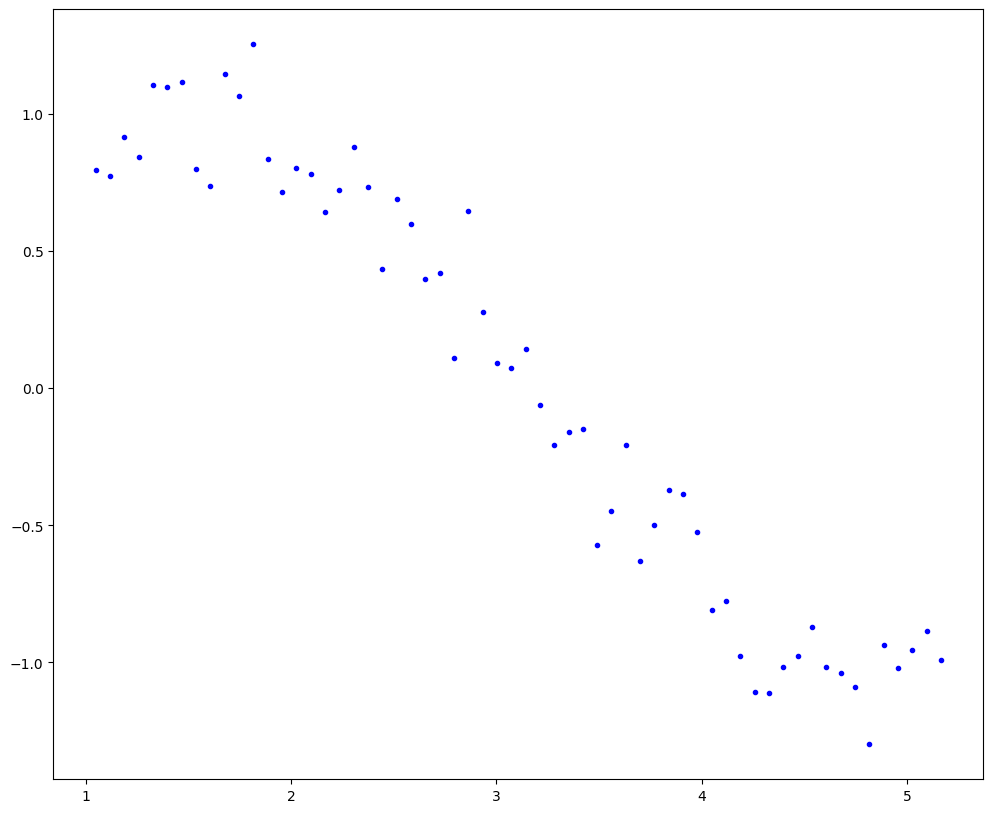

In [16]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 12, 10 #dimension fenetre du plot

#Define input array with angles from 60deg to 300deg converted to radians
x = np.array([i*np.pi/180 for i in range(60,300,4)])
#print(x)
np.random.seed(777)  #Jackpot
y = np.sin(x) + np.random.normal(0,0.15,len(x))
#print(np.random.normal(0,0.15,len(x)))
#plt.hist(np.random.normal(0,0.15,len(x)),50)
data = pd.DataFrame(np.column_stack([x,y]),columns=['x','y'])
print(data.head())


#faites plot de x Vs Y

plt.plot(x, y,'.', color='b')



In [17]:
for i in range(2,16):  #power of 1 is already there
    colname = 'x_%d'%i      #new var will be x_power
    data[colname] = data['x']**i

In [18]:
print(data.head())
print(data['x_2'].head())
print(data[['x', 'x_2']].head())

          x         y       x_2       x_3       x_4       x_5       x_6  \
0  1.047198  0.795794  1.096623  1.148381  1.202581  1.259340  1.318778   
1  1.117011  0.775370  1.247713  1.393709  1.556788  1.738948  1.942424   
2  1.186824  0.917377  1.408551  1.671702  1.984016  2.354677  2.794587   
3  1.256637  0.844052  1.579137  1.984402  2.493673  3.133642  3.937850   
4  1.326450  1.106248  1.759470  2.333850  3.095735  4.106339  5.446854   

        x_7       x_8        x_9       x_10       x_11       x_12       x_13  \
0  1.381021  1.446202   1.514459   1.585938   1.660790   1.739176   1.821260   
1  2.169709  2.423588   2.707173   3.023942   3.377775   3.773011   4.214494   
2  3.316683  3.936319   4.671717   5.544505   6.580351   7.809718   9.268760   
3  4.948448  6.218404   7.814277   9.819710  12.339811  15.506664  19.486248   
4  7.224981  9.583578  12.712139  16.862020  22.366630  29.668222  39.353420   

        x_14       x_15  
0   1.907219   1.997235  
1   4.707635   5

In [19]:
data.shape

(60, 16)

$X$ : la matrice des données ou caractéristiques (features) (nrow: $N$, ncol: $M+1$)
$Y$ : la variable de sortie  (length:$N$)
$\hat Y$:les valeurs prédites de $Y$ (length:$N$)
$W$: les poids ou coefficients de régréssion (length: $M+1$).

Ici, $N$ est le nombre total des points données dont on dispose et $M$ est le nombre total de caractéristiques. $X$ a $M+1$ colonnes  car  elle a $M$ features et 1 intercept (constante).

Pour chaque point $i$ la prédiction est 

$$
\hat y_i=\sum_{j=0}^M w_j x_i^j
$$

L'expression à minimiser pour la régréssion est ${\rm RSS}$ (Residual Sum of Squares) définie par :

$$
{\rm RSS}(w):=\sum_{i=1}^N\left(y_i-\hat y_i\right)^2
$$

In [ ]:
#Import Linear Regression model from scikit-learn.
# pip install sklearn 
from sklearn.linear_model import LinearRegression

def linear_regression(data, power, models_to_plot):
    #initialize predictors:
    predictors=['x'] # label
    
    if power>=2:
        predictors.extend(['x_%d'%i for i in range(2,power+1)])
    
    if power>=16:
       print('Powers larger than 16 not defined on the database')
    #print(predictors)
    
    
    # Fit the model
    linreg = LinearRegression() #In theory, normalising the predictors 
                                             #will not affect the predictions made by linear regression. 
                                            #However, there are some practical reasons for doing so.
    
    # data[predictors] = data[predictors] - np.mean(data[predictors]) / np.sqrt(np.var(data[predictors]))
    
    linreg.fit(data[predictors], data['y']) # find optimal weights w

    y_pred = linreg.predict(data[predictors])  # \hat y   compute  ΣwX
    
    
    #Check if a plot is to be made for the entered power
    if power in models_to_plot:
        plt.subplot(models_to_plot[power])
        plt.tight_layout()
        plt.plot(data['x'],y_pred, linewidth=4, color = 'r')
        plt.plot(data['x'],data['y'],'.',color = 'b')
        plt.title('Plot for power: %d'%power)
    
    #Return the result in pre-defined format
    rss = sum((y_pred- data['y'])**2)

    ret = [rss]
    #Reminder
    #x = [1, 2, 3] x.append([4, 5]) print (x) [1, 2, 3, [4, 5]]
    #x = [1, 2, 3] x.extend([4, 5]) print (x) [1, 2, 3, 4, 5]
    
    ret.extend([linreg.intercept_]) # constante de regression w0
    ret.extend(linreg.coef_) # les autres coefficients w1,... wpower
    return ret

In [21]:
#Initialize a dataframe to store the results:
col = ['rss','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['model_pow_%d'%i for i in range(1,16)]
coef_matrix_simple = pd.DataFrame(index=ind, columns=col)
#print(coef_matrix_simple)

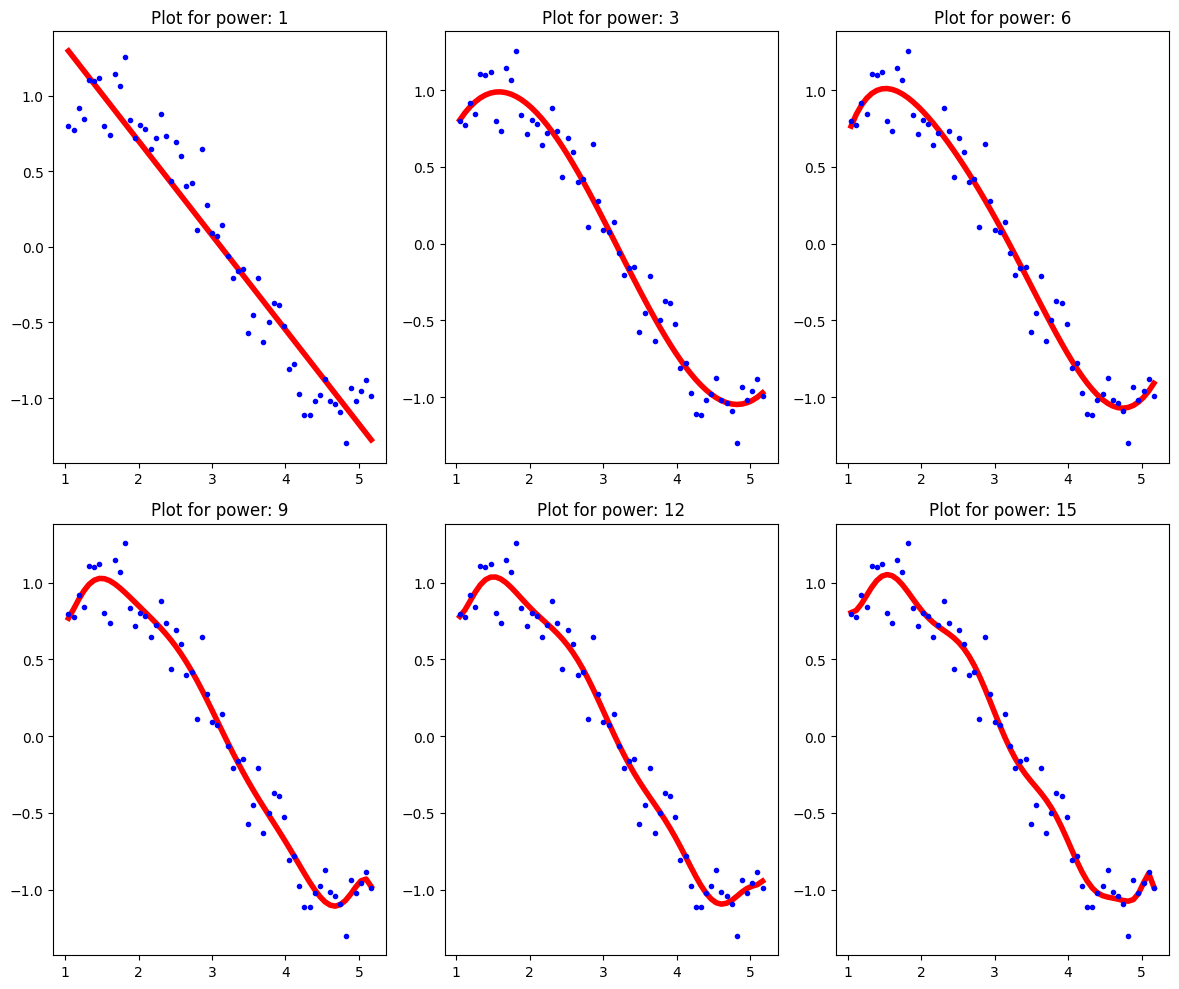

In [29]:
rcParams['figure.figsize'] = 12, 10

#Define the powers for which a plot is required:
models_to_plot = {1:231,3:232,6:233,9:234,12:235,15:236} #dictionnary where 1, 3, 6, 9, 12 and 15 are 
                                                        #the powers to be plot

# 23 veut dire que les plots seront sur 2 lignes et 3 colonnes.

#for power in models_to_plot:
#    print(power)
#    print(models_to_plot[power])



#Iterate through all powers and assimilate results
for i in range(1,16):
    coef_matrix_simple.iloc[i-1,0:i+2] = linear_regression(data, power=i, models_to_plot=models_to_plot)
#pour i=1
#ret=[rss,intecept, coef_1]

In [30]:
#Set the display format to be scientific for ease of analysis
#pd.options.display.float_format = '{:,.2g}'.format
coef_matrix_simple

,rss,intercept,coef_x_1,coef_x_2,coef_x_3,coef_x_4,coef_x_5,coef_x_6,coef_x_7,coef_x_8,coef_x_9,coef_x_10,coef_x_11,coef_x_12,coef_x_13,coef_x_14,coef_x_15
model_pow_1,3.00292,1.948944,-0.624285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_2,2.889391,1.676354,-0.417477,-0.033284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_3,1.234969,-0.936539,2.735806,-1.149697,0.119786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_4,1.225881,-0.442955,1.921448,-0.693187,0.01503,0.00843,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_5,1.202404,-2.480399,6.177905,-3.981141,1.199064,-0.192247,0.012919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_6,1.198729,-4.560663,11.433066,-9.165706,3.768272,-0.870805,0.104041,-0.004888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_7,1.198552,-5.743244,14.935767,-13.37465,6.435759,-1.837566,0.305273,-0.027259,0.001029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_8,1.185251,-32.40843,105.505347,-141.718996,105.728104,-47.828053,13.405183,-2.275321,0.214202,-0.008577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_9,1.161835,59.943316,-248.219785,435.780117,-422.404898,250.877226,-95.19084,23.16412,-3.497711,0.298274,-0.010975,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_10,1.154293,197.307628,-833.78369,1517.941701,-1565.161331,1015.506701,-434.48543,124.468668,-23.632801,2.852857,-0.198144,0.006025,NaN,NaN,NaN,NaN,NaN


## Ridge régression

$$
{\rm RSS}(w):=\sum_{i=1}^N\left(y_i-\sum_{j=0}^Mw_jx_i^j\right)^2+\lambda \sum_{j=0}^M w_j^2
$$

In [ ]:
from sklearn.linear_model import Ridge
def ridge_regression(data, predictors, alpha, models_to_plot={}):
    #Fit the model
    ridgereg = Ridge(alpha=alpha) #alpha c'est lambda
    ridgereg.fit(X=data[predictors], y= data['y'])
    y_pred = ridgereg.predict(data[predictors])
    
    #Check if a plot is to be made for the entered alpha
    if alpha in models_to_plot:
        plt.subplot(models_to_plot[alpha])
        plt.tight_layout()
        plt.plot(data['x'],y_pred, linewidth=4, color = 'r')
        plt.plot(data['x'],data['y'],'.',color = 'b')
        plt.title('Plot for alpha: %.3g'%alpha)
    
    #Return the result in pre-defined format
    rss = sum((data['y']-y_pred)**2)
    ret = [rss]
    ret.extend([ridgereg.intercept_])
    ret.extend(ridgereg.coef_)
    return ret

c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=4.04792e-26): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=2.41282e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=7.89039e-23): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\_util.py:1226: LinAlgWarning: Ill-conditioned matrix (rcond=3.69428e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\_lib\

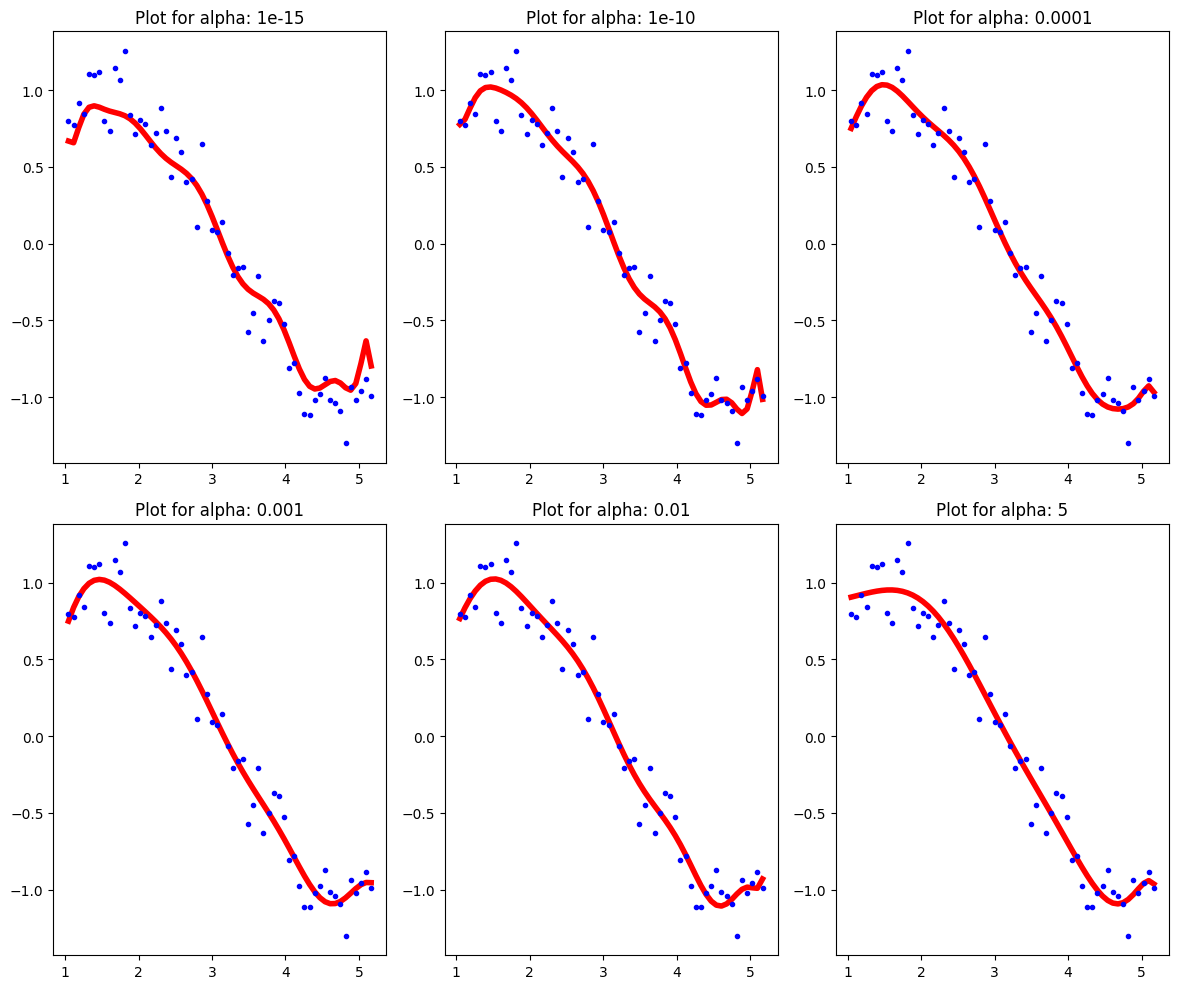

In [37]:
#Initialize predictors to be set of 15 powers of x
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])

#Set the different values of alpha to be tested
alpha_ridge = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20]

#Initialize the dataframe for storing coefficients.
col = ['rss','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['alpha_%.2g'%alpha_ridge[i] for i in range(0,10)]
coef_matrix_ridge = pd.DataFrame(index=ind, columns=col)

models_to_plot = {1e-15:231, 1e-10:232, 1e-4:233, 1e-3:234, 1e-2:235, 5:236}
for i in range(10):
    coef_matrix_ridge.iloc[i,] = ridge_regression(data, predictors, alpha_ridge[i], models_to_plot)

In [26]:
#Set the display format to be scientific for ease of analysis
#pd.options.display.float_format = '{:,.2g}'.format
coef_matrix_ridge

,rss,intercept,coef_x_1,coef_x_2,coef_x_3,coef_x_4,coef_x_5,coef_x_6,coef_x_7,coef_x_8,coef_x_9,coef_x_10,coef_x_11,coef_x_12,coef_x_13,coef_x_14,coef_x_15
alpha_1e-15,1.657239,5566.306821,-32099.576379,84138.807323,-133368.451006,143548.540442,-111692.479616,65281.735001,-29364.108054,10304.116586,-2831.234536,604.890628,-98.548971,11.812318,-0.979181,0.049979,-0.00118
alpha_1e-10,1.04612,443.361898,-1660.871046,2131.081009,-437.863795,-1478.078351,1153.364846,563.661724,-1497.812924,1219.585917,-588.816366,189.294593,-41.788553,6.288634,-0.618283,0.035868,-0.000932
alpha_1e-08,1.063834,-5.824372,-51.761144,177.226647,-110.598164,-161.558859,212.818823,73.684331,-324.101429,314.144009,-171.987131,61.11938,-14.658028,2.365352,-0.246839,0.015075,-0.00041
alpha_0.0001,1.123989,1.899961,-3.011585,-0.884479,2.68291,2.869041,-1.393128,-3.934758,1.173689,4.326436,-4.980546,2.627671,-0.820144,0.160448,-0.019415,0.001334,-0.00004
alpha_0.001,1.153834,-1.288152,0.974034,1.426745,0.80312,-0.653851,-1.422474,0.07845,1.910582,-1.687913,0.643055,-0.104628,-0.005432,0.005493,-0.000998,0.000083,-0.000003
alpha_0.01,1.16639,-0.029764,0.137325,0.298685,0.415879,0.349237,-0.045173,-0.619716,-0.535627,1.599345,-1.272829,0.531608,-0.131927,0.019774,-0.001693,0.000069,-0.000001
alpha_1,1.216545,0.741574,0.028452,0.049047,0.052405,0.032838,-0.002714,-0.029437,-0.019478,0.016356,0.013717,-0.017939,0.008305,-0.002091,0.000305,-0.000024,0.000001
alpha_5,1.232404,0.847114,0.008334,0.015435,0.018656,0.01555,0.006092,-0.004894,-0.008739,-0.001619,0.005196,-0.001312,-0.000396,0.000264,-0.000056,0.000005,-0.0
alpha_10,1.236434,0.873096,0.004912,0.009424,0.01204,0.011129,0.006058,-0.001214,-0.005753,-0.003315,0.002553,0.00136,-0.001454,0.000488,-0.000082,0.000007,-0.0
alpha_20,1.239944,0.893524,0.002876,0.005706,0.007666,0.007719,0.005155,0.00056,-0.00347,-0.003489,0.000605,0.002525,-0.001681,0.000478,-0.000071,0.000006,-0.0


In [32]:
# determining the number of zeros in each row of the coefficients data set:
coef_matrix_ridge.apply(lambda x: sum(x.values==0),axis=1)

alpha_1e-15     0
alpha_1e-10     0
alpha_1e-08     0
alpha_0.0001    0
alpha_0.001     0
alpha_0.01      0
alpha_1         0
alpha_5         0
alpha_10        0
alpha_20        0
dtype: int64

## Lasso Régression

$$
{\rm RSS}(w):=\sum_{i=1}^N\left(y_i-\sum_{j=0}^Mw_jx_i^j\right)^2+\lambda \sum_{j=0}^M |w_j|
$$

In [40]:
from sklearn.linear_model import Lasso
def lasso_regression(data, predictors, alpha, models_to_plot={}):
    #Fit the model
    lassoreg = Lasso(alpha=alpha, max_iter=int(1e5))
    #Fit the model
    lassoreg.fit(X=data[predictors], y= data['y'])
    y_pred = lassoreg.predict(data[predictors])
    
    #Check if a plot is to be made for the entered alpha
    if alpha in models_to_plot:
        plt.subplot(models_to_plot[alpha])
        plt.tight_layout()
        plt.plot(data['x'],y_pred, linewidth=4, color = 'r')
        plt.plot(data['x'],data['y'],'.',color = 'b')
        plt.title('Plot for alpha: %.3g'%alpha)
    
    #Return the result in pre-defined format
    rss = sum((data['y']-y_pred)**2)
    ret = [rss]
    ret.extend([lassoreg.intercept_])
    ret.extend(lassoreg.coef_)
    return ret

In [38]:
#Initialize predictors to all 15 powers of x
#complétez

for i in range(2,16):  #power of 1 is already there
    colname = 'x_%d'%i      #new var will be x_power
    data[colname] = data['x']**i

c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.030e-01, tolerance: 3.718e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.030e-01, tolerance: 3.718e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

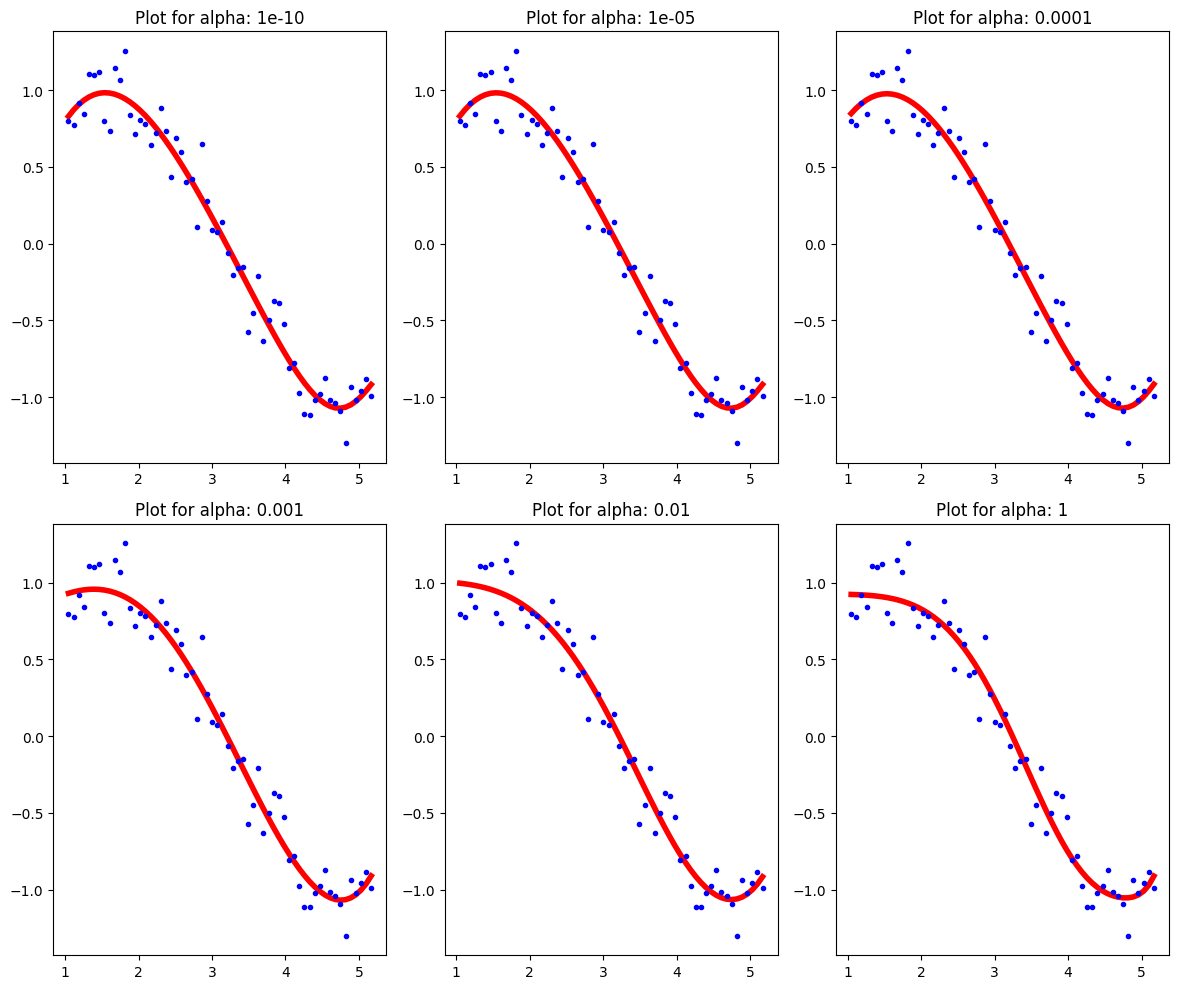

In [41]:
#Initialize predictors to all 15 powers of x
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])

#Define the alpha values to test
alpha_lasso = [1e-15, 1e-10, 1e-8, 1e-5,1e-4, 1e-3,1e-2, 1, 5, 10]

#Initialize the dataframe to store coefficients
col = ['rss','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['alpha_%.2g'%alpha_lasso[i] for i in range(0,10)]
coef_matrix_lasso = pd.DataFrame(index=ind, columns=col)

#Define the models to plot
models_to_plot = {1e-10:231, 1e-5:232,1e-4:233, 1e-3:234, 1e-2:235, 1:236}

#Iterate over the 10 alpha values:
for i in range(10):
    coef_matrix_lasso.iloc[i,] = lasso_regression(data, predictors, alpha_lasso[i], models_to_plot)

In [42]:
#pd.options.display.float_format = '{:,.2g}'.format
coef_matrix_lasso

,rss,intercept,coef_x_1,coef_x_2,coef_x_3,coef_x_4,coef_x_5,coef_x_6,coef_x_7,coef_x_8,coef_x_9,coef_x_10,coef_x_11,coef_x_12,coef_x_13,coef_x_14,coef_x_15
alpha_1e-15,1.206075,-0.784268,2.527844,-1.021511,0.061823,0.012459,0.000475,-0.000161,-0.000042,-0.000005,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_1e-10,1.206075,-0.784268,2.527844,-1.021511,0.061823,0.012459,0.000475,-0.000161,-0.000042,-0.000005,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_1e-08,1.206076,-0.784234,2.527785,-1.021476,0.061815,0.012459,0.000475,-0.000161,-0.000042,-0.000005,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_1e-05,1.206642,-0.749947,2.468236,-0.986587,0.054199,0.012677,0.000534,-0.000154,-0.000042,-0.000005,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_0.0001,1.212692,-0.451278,1.958392,-0.697252,-0.003956,0.012793,0.001122,-0.000086,-0.000038,-0.000006,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_0.001,1.265313,0.711026,0.155153,0.163525,-0.103184,-0.007,0.002889,0.000342,0.000001,-0.000006,-0.000001,-0.0,0.0,0.0,0.0,0.0,-0.0
alpha_0.01,1.330416,1.00913,0.0,0.0,0.0,-0.008997,-0.002765,0.000564,0.000087,0.000003,-0.000001,-0.0,-0.0,-0.0,0.0,0.0,0.0
alpha_1,1.387253,0.925302,-0.0,-0.0,-0.0,-0.0,-0.0,-0.002291,0.00019,0.0001,0.000001,-0.000001,-0.0,-0.0,-0.0,0.0,0.0
alpha_5,1.605066,0.867163,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000528,-0.000449,0.000075,0.00002,-0.0,-0.0,-0.0,-0.0,0.0,0.0
alpha_10,1.747649,0.843496,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000516,-0.0,0.000035,0.000001,-0.0,-0.0,-0.0,-0.0,0.0


In [43]:
coef_matrix_lasso.apply(lambda x: sum(x.values==0),axis=1)

alpha_1e-15     0
alpha_1e-10     0
alpha_1e-08     0
alpha_1e-05     0
alpha_0.0001    0
alpha_0.001     0
alpha_0.01      3
alpha_1         5
alpha_5         5
alpha_10        7
dtype: int64